# Instalando dependências

In [ ]:
%pip install numpy
%pip install matplotlib

# Importando bibliotecas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Vetor de frequências de 0 a 40 rad/s

In [ ]:
w_min, w_max = 0.0, 40.0
w = np.linspace(w_min, w_max, 4000)  # vetor de frequências (rad/s)


# 2.1 Filto de Chebyshev

# Função para calcular os coeficientes do polinômio de Chebyshev

In [ ]:
def calcula_coeficientes(w, wc, n):
    w = np.asarray(w)
    Tn = np.zeros_like(w, dtype=float)
    mask1 = np.abs(w) < wc
    mask2 = np.abs(w) >= wc
    ratio1 = np.zeros_like(w)
    ratio1[mask1] = w[mask1] / wc
    ratio1 = np.clip(ratio1, -1.0, 1.0)
    Tn[mask1] = np.cos(n * np.arccos(ratio1[mask1]))
    ratio2 = np.zeros_like(w)
    ratio2[mask2] = np.abs(w[mask2]) / wc
    ratio2 = np.maximum(ratio2, 1.0)
    Tn[mask2] = np.cosh(n * np.arccosh(ratio2[mask2]))
    return Tn

# Função que retorna o módulo da resposta em frequência para o filtro de Chebyshev $$|H_C(j \omega)| = \frac{1}{\sqrt {1 + ϵ^2 T_n^2(\frac {ω}{\omega_c})}}$$

In [ ]:
def chebyshev_mag(w, wc, n, eps):
    Tn = calcula_coeficientes(w, wc, n)
    return 1.0 / np.sqrt(1.0 + (eps**2) * (Tn**2))

## Item a)

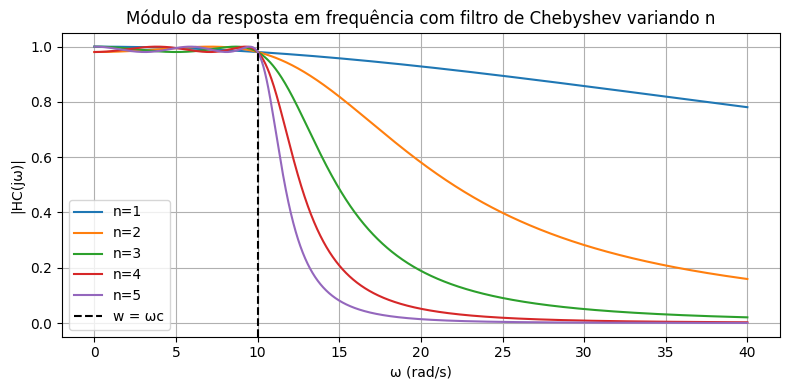

In [ ]:
wc = 10 # rad/s
eps_a = 0.2
plt.figure(figsize=(8,4))
for n in range(1,6):
    H = chebyshev_mag(w, wc, n, eps_a)
    plt.plot(w, H, label='n='+str(n))
plt.title('Módulo da resposta em frequência com filtro de Chebyshev variando n')
plt.xlabel('ω (rad/s)'); plt.ylabel('|HC(jω)|')
plt.axvline(wc, color = 'k', linestyle = '--', label = 'w = ωc')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Item b)

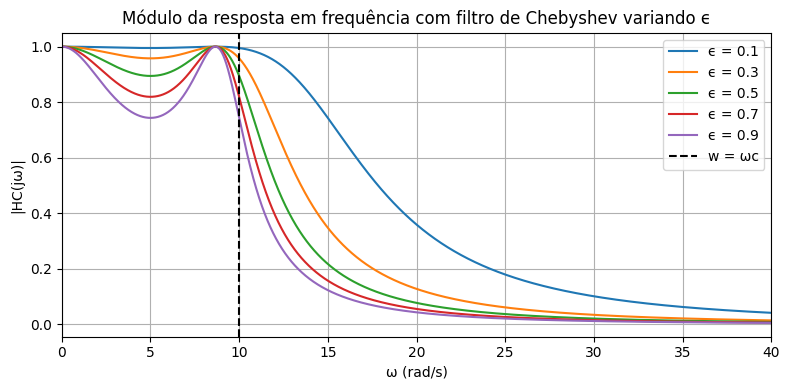

In [ ]:
n = 3
eps_0 = 0.1
plt.figure(figsize=(8,4))
for i in range(5):
  H = chebyshev_mag(w, wc, n, eps_0)
  plt.plot(w, H, label = f'ϵ = {eps_0:.1f}')
  eps_0 += 0.2
plt.title('Módulo da resposta em frequência com filtro de Chebyshev variando ϵ')
plt.xlabel('ω (rad/s)'); plt.ylabel('|HC(jω)|')
plt.axvline(wc, color = 'k', linestyle = '--', label = 'w = ωc')
plt.legend()
plt.grid(True)
plt.xlim(0,40)
plt.tight_layout()
plt.show()

# 2.2 Filtro de Butterworth

# Função que retorna o módulo da resposta em frequência para o filtro de Butterworth $$|H_B(j \omega)| = \frac{1}{\sqrt {1 + (\frac {\omega}{\omega_0})^{2n}}}$$

In [ ]:
def butterworth_mag(w, wc, n):
  return 1.0 / np.sqrt(1 + (w/wc)**(2*n))

## Item c)

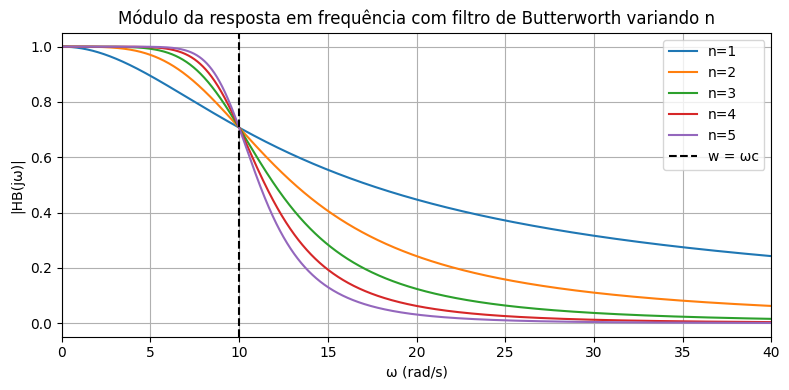

In [ ]:
wc = 10 # rad/s
plt.figure(figsize=(8,4))
for n in range(1,6):
    H = butterworth_mag(w, wc, n)
    plt.plot(w, H, label='n='+str(n))
plt.title('Módulo da resposta em frequência com filtro de Butterworth variando n')
plt.xlabel('ω (rad/s)'); plt.ylabel('|HB(jω)|')
plt.axvline(wc, color = 'k', linestyle = '--', label = 'w = ωc')
plt.legend()
plt.grid(True)
plt.xlim(0,40)
plt.tight_layout()
plt.show()

# 2.3 Filtro de um pulso retangular

# Função que retorna a transformada de fourier para um pulso $x(t)$ retangular
$$X(j \omega) = {\tau}Sa \left(\frac {\omega \tau}{2} \right) $$

In [ ]:
def transf_fourrier(w, tau):
  return np.abs(2*np.sin(w*tau/2)/w)

## Item d)

/tmp/ipython-input-1989959720.py:2: RuntimeWarning: invalid value encountered in divide
  return np.abs(2*np.sin(w*tau/2)/w)


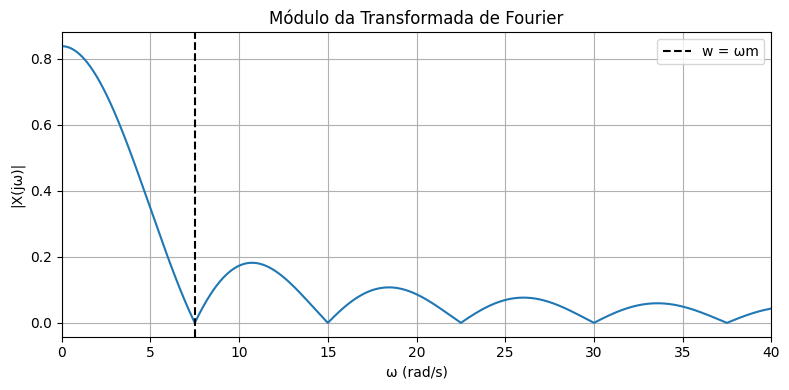

In [ ]:
wm = 7.5 # rad/s
tau = 2*np.pi/wm
plt.figure(figsize=(8,4))
H = abs(transf_fourrier(w, tau))
plt.plot(w, H)
plt.title('Módulo da Transformada de Fourier')
plt.xlabel('ω (rad/s)'); plt.ylabel('|X(jω)|')
plt.axvline(wm, color = 'k', linestyle = '--', label = 'w = ωm')
plt.legend()
plt.grid(True)
plt.xlim(0,40)
plt.tight_layout()
plt.show()

# Função que retorna a resposta em frequência para um FPB ideal
$$H_{ideal}(j \omega) =
\begin{cases}
1, & |\omega| \leq \omega_c \\
0, & \text{caso contrário}.
\end{cases}$$

In [ ]:
def Hideal(w, wc):
  return np.where(np.abs(w) <= wc, 1, 0)

## Item e)

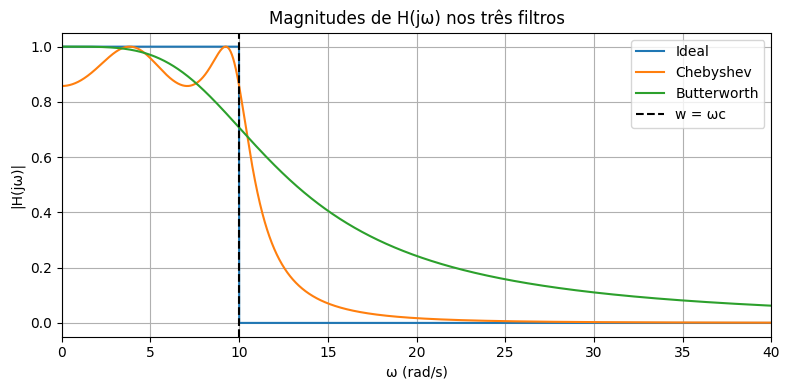

/tmp/ipython-input-1989959720.py:2: RuntimeWarning: invalid value encountered in divide
  return np.abs(2*np.sin(w*tau/2)/w)


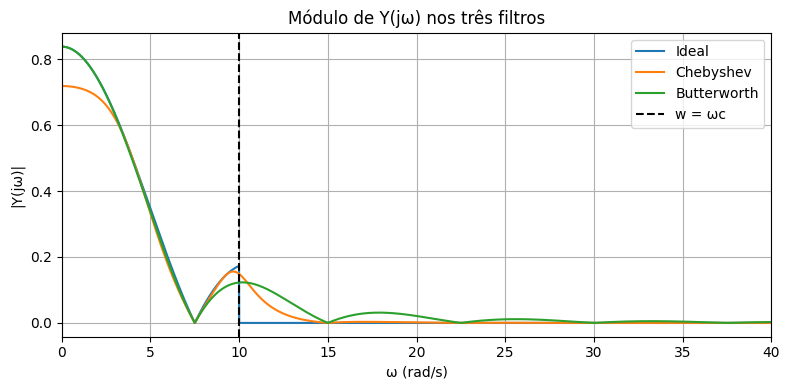

In [ ]:
wc = 10 # rad/s
H_ideal = Hideal(w, wc)
plt.figure(figsize=(8,4))
plt.plot(w,H_ideal, label = 'Ideal')

eps = 0.6
n = 4
Hc = chebyshev_mag(w, wc, n, eps)
plt.plot(w,Hc, label = 'Chebyshev')

n = 2
Hb = butterworth_mag(w, wc, n)
plt.plot(w,Hb, label = 'Butterworth')

plt.title('Magnitudes de H(jω) nos três filtros')
plt.xlabel('ω (rad/s)'); plt.ylabel('|H(jω)|')
plt.axvline(wc, color = 'k', linestyle = '--', label = 'w = ωc')
plt.legend()
plt.grid(True)
plt.xlim(0,40)
plt.tight_layout()
plt.show()

wc = 10 # rad/s
Y_ideal = H_ideal*transf_fourrier(w, tau)
plt.figure(figsize=(8,4))
plt.plot(w,Y_ideal, label = 'Ideal')

Yc = Hc*transf_fourrier(w, tau)
plt.plot(w,Yc, label = 'Chebyshev')

Yb = Hb*transf_fourrier(w, tau)
plt.plot(w,Yb, label = 'Butterworth')

plt.title('Módulo de Y(jω) nos três filtros')
plt.xlabel('ω (rad/s)'); plt.ylabel('|Y(jω)|')
plt.axvline(wc, color = 'k', linestyle = '--', label = 'w = ωc')
plt.legend()
plt.grid(True)
plt.xlim(0,40)
plt.tight_layout()
plt.show()

#